Based on lrg_redshift_distributions-sv1_and_sv3.ipynb

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
from matplotlib.ticker import FormatStrFormatter
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [3]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [4]:
# Denali

tmp = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/denali/testdenali/All/alltiles_Allzinfo.fits', columns=['SV1_DESI_TARGET', 'TARGETS', 'coadd_type']))
mask = (tmp['SV1_DESI_TARGET'] & 2**0 > 0) & (tmp['TARGETS']=='QSO+LRG') & (tmp['coadd_type']=='cumulative')
idx = np.where(mask)[0]
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/denali/testdenali/All/alltiles_Allzinfo.fits', rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Require a minimum depth for the deep coadd
min_depth = 2000.
mask = zbest['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

zbest.rename_columns(['TARGET_RA', 'TARGET_DEC'], ['RA', 'DEC'])

52268
52023
FIBERSTATUS 43371 8897 0.17021887196755184
No data 43368 3 6.917064397869545e-05
Min depth 36843 6525 0.8495434421693414


In [5]:
# SV3

zbest_path = '/global/cfs/cdirs/desi/survey/catalogs/SV3/LSS/LSScats/v0/LRGAlltiles_full.dat.fits'
zbest1 = Table(fitsio.read(zbest_path))
print(len(zbest1))
print(len(np.unique(zbest1['TARGETID'])))

# Remove FIBERSTATUS!=0 fibers
mask = zbest1['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest1 = zbest1[mask]

# Remove "no data" fibers
mask = zbest1['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest1 = zbest1[mask]

# Require a minimum depth for the deep coadd
min_tsnr_lrg = 80.
mask = zbest1['TSNR2_LRG']>min_tsnr_lrg
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest1 = zbest1[mask]

103823
103823
FIBERSTATUS 98822 5001 0.04816851757317743
No data 98822 0 0.0
Min depth 93944 4878 0.9506385217866467


In [6]:
columns = np.intersect1d(zbest.colnames, zbest1.colnames)
print(columns)
zbest = zbest[list(columns)]
zbest1 = zbest1[list(columns)]

zbest['program'] = 'sv1'
zbest1['program'] = 'sv3'

['BRICKID' 'BRICKNAME' 'BRICK_OBJID' 'CHI2' 'COEFF' 'DEC' 'DELTACHI2'
 'EBV' 'FIBER' 'FIBERFLUX_G' 'FIBERFLUX_R' 'FIBERFLUX_Z' 'FIBERSTATUS'
 'FIBERTOTFLUX_G' 'FIBERTOTFLUX_R' 'FIBERTOTFLUX_Z' 'FLUX_G' 'FLUX_IVAR_G'
 'FLUX_IVAR_R' 'FLUX_IVAR_W1' 'FLUX_IVAR_W2' 'FLUX_IVAR_Z' 'FLUX_R'
 'FLUX_W1' 'FLUX_W2' 'FLUX_Z' 'LOCATION' 'MASKBITS' 'MORPHTYPE' 'NCOEFF'
 'NPIXELS' 'NUMOBS_INIT' 'OBSCONDITIONS' 'PARALLAX' 'PHOTSYS' 'PMDEC'
 'PMRA' 'PRIORITY' 'PRIORITY_INIT' 'PSF_TO_FIBER_SPECFLUX' 'RA'
 'REF_EPOCH' 'RELEASE' 'SPECTYPE' 'SUBPRIORITY' 'SUBTYPE' 'TARGETID'
 'TSNR2_BGS' 'TSNR2_ELG' 'TSNR2_LRG' 'TSNR2_QSO' 'Z' 'ZERR' 'ZWARN']


In [7]:
zbest = vstack([zbest, zbest1])
print(len(zbest), len(np.unique(zbest['TARGETID'])))

130787 129994


In [8]:
# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*zbest['Z']))
mask_remove = (d>30) & (zbest['DELTACHI2']<30)
mask_remove |= (d<30) & (zbest['DELTACHI2']<d)
mask_remove |= (zbest['DELTACHI2']<10)
mask_quality = zbest['ZWARN']==0
mask_quality &= zbest['Z']<1.4
mask_quality &= (~mask_remove)
print(np.sum(~mask_quality)/len(mask_quality))

zbest = zbest[mask_quality]
print(len(zbest), len(np.unique(zbest['TARGETID'])))

0.019604394932218033
128223 127448


In [9]:
# # Remove duplicates
# _, idx = np.unique(zbest['TARGETID'], return_index=True)
# zbest = zbest[idx]
# print(len(zbest), len(np.unique(zbest['TARGETID'])))

__Add MEDIUM mask__

In [10]:
maskbits = [8, 9]

mask_clean = np.ones(len(zbest), dtype=bool)
for bit in maskbits:
    mask_clean &= (zbest['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean), np.sum(~mask_clean)/len(mask_clean))

# mask_clean &= (zbest['NOBS_G']>=min_nobs) & (zbest['NOBS_R']>=min_nobs) & (zbest['NOBS_Z']>=min_nobs)
# print(np.sum(~mask_clean)/len(mask_clean))

zbest = zbest[mask_clean]
print(len(zbest), len(np.unique(zbest['TARGETID'])))

1285 0.010021602988543397
126938 126164


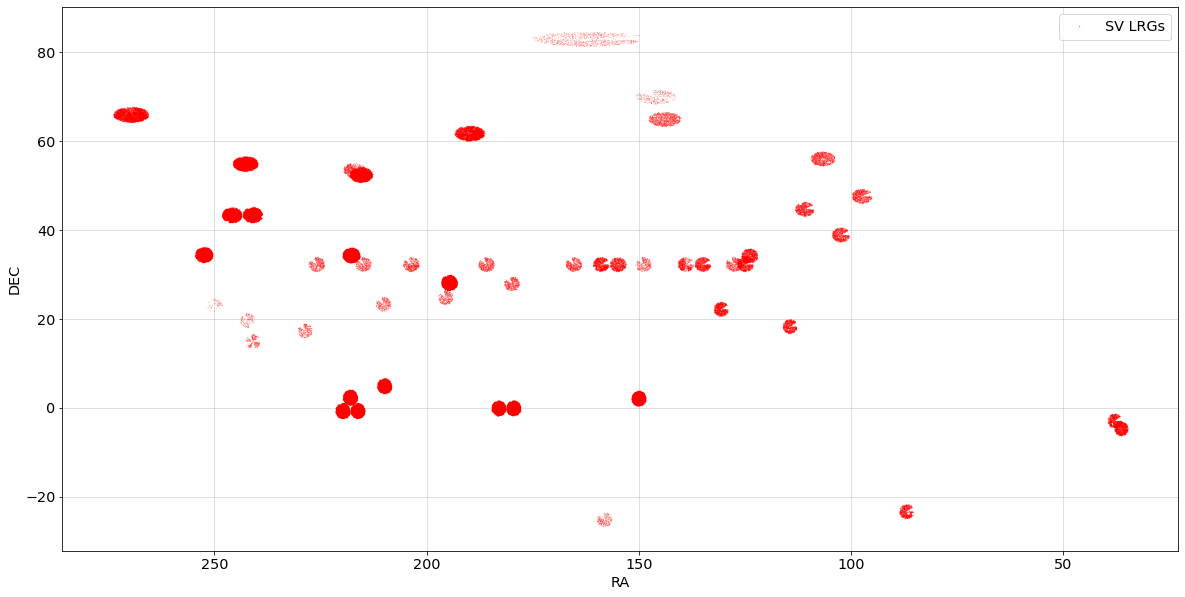

In [11]:
plt.figure(figsize=(20, 10))
plt.plot(zbest['RA'], zbest['DEC'], 'r.', ms=.1, label='SV LRGs')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [12]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G']) - 3.214 * zbest['EBV']
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R']) - 2.165 * zbest['EBV']
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z']) - 1.211 * zbest['EBV']
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1']) - 0.184 * zbest['EBV']
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2']) - 0.113 * zbest['EBV']
    zbest['gfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_G']) - 3.214 * zbest['EBV']
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R']) - 2.165 * zbest['EBV']
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z']) - 1.211 * zbest['EBV']

In [13]:
gmag = zbest['gmag']
rmag = zbest['rmag']
zmag = zbest['zmag']
w1mag = zbest['w1mag']
w2mag = zbest['w2mag']
rfibermag = zbest['rfibermag']
zfibermag = zbest['zfibermag']
# gaia_g = zbest['GAIA_PHOT_G_MEAN_MAG']

mask_north = zbest['PHOTSYS']=='N'
mask_south = zbest['PHOTSYS']=='S'

In [14]:
# SV3 selection

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.26) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.36) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.29
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.3) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.13)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

# mask_bright = (gaia_g!=0) & (gaia_g < 18)
# lrg_mask &= (~mask_bright)

lrg_sv3_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.72)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.24) * 1.83 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.39
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.34) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.23)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

# mask_bright = (gaia_g!=0) & (gaia_g < 18)
# lrg_mask &= (~mask_bright)

lrg_sv3_north = lrg_mask.copy()

lrg_sv3 = lrg_sv3_south | lrg_sv3_north
print(np.sum(lrg_sv3))

105230


In [16]:
print(np.unique(zbest['program'][lrg_sv3], return_counts=True))

(<Column name='program' dtype='str3' length=2>
sv1
sv3, array([12931, 92299]))


In [15]:
# Final selection

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.6)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.14) * 1.8  # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.3
lrg_mask &= lrg_mask_sliding

mask_lowz = gmag - w1mag > 2.9  # low-z cut
mask_lowz |= rmag - w1mag > 1.8  # low-z cut
lrg_mask &= mask_lowz

# mask_bright = (gaia_g!=0) & (gaia_g < 18)
# lrg_mask &= (~mask_bright)

# lrg_mask &= (zfibertotmag>17.5)

lrg_new_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.61)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.13) * 1.83  # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.31) * 1.   # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.4
lrg_mask &= lrg_mask_sliding

mask_lowz = gmag - w1mag > 2.97  # low-z cut
mask_lowz |= rmag - w1mag > 1.8  # low-z cut
lrg_mask &= mask_lowz

# mask_bright = (gaia_g!=0) & (gaia_g < 18)
# lrg_mask &= (~mask_bright)

# lrg_mask &= (zfibertotmag>17.5)

lrg_new_north = lrg_mask.copy()

lrg_new = lrg_new_south | lrg_new_north
print(np.sum(lrg_new))

79453


In [15]:
print(np.unique(zbest['program'][lrg_new], return_counts=True))

(<Column name='program' dtype='str3' length=2>
sv1
sv3, array([ 9790, 69663]))


In [17]:
mask = zbest['program']=='sv3'
weights = np.ones(len(zbest))
weights[mask] = 1/10

In [18]:
# numbers from another notebook
area_tot = 10109.0
n_lrg_new_tot = 6159414
density_tot = n_lrg_new_tot/area_tot
print(density_tot)

area = np.sum(weights[lrg_new])/n_lrg_new_tot * area_tot
print(area)

609.3000296765259
27.500901335743958


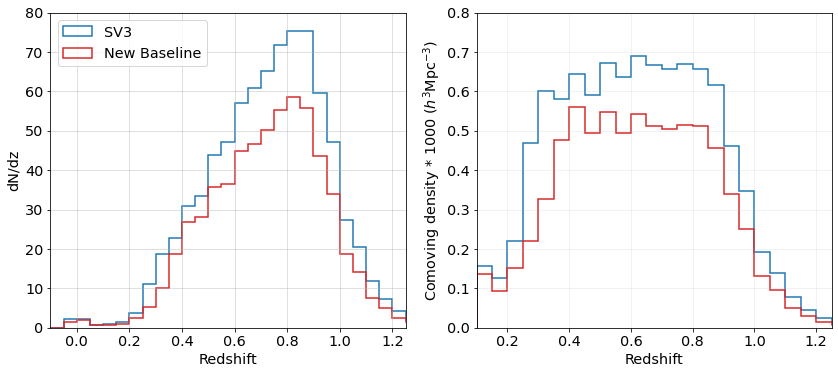

In [37]:
bins = np.arange(-0.1, 1.45, 0.05)
bin_centers = (bins[1:]+bins[:-1])/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].hist(zbest['Z'][lrg_sv3], bins=bins, lw=1.5,
             weights=weights[lrg_sv3]/area, histtype='step', label='SV3', color='C0')
axes[0].hist(zbest['Z'][lrg_new], bins=bins, lw=1.5,
             weights=weights[lrg_new]/area, histtype='step', label='New Baseline', color='C3')
# axes[0].hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].set_ylim(0, 80)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_sv3], area=area, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False, weights=weights[lrg_sv3])
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_new], area=area, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C3', errorbar=False, weights=weights[lrg_new])
# plt.legend(loc='lower left')
plt.show()